In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [56]:
file = 'data/DES-Dovekie_HD.csv'

with open(file) as f:
    for i, line in enumerate(f):
        if line.startswith('VARNAMES:'):
            header_line = line
            header_idx = i
            break

cols = header_line.replace("VARNAMES:", "").split()

df = pd.read_csv(file, sep='\s+', skiprows=header_idx + 1, header=None).iloc[:, 1:]
df.columns = cols

low_z = df[df['IDSURVEY'] != 10]
high_z = df[df['IDSURVEY'] == 10]
high_z

,CID,IDSURVEY,zHD,zHEL,MU,MUERR,MUERR_VPEC,MUERR_SYS,PROBIA_BEAMS
187,1371046,10,0.07334,0.07411,37.60807,0.1792,0.0307,0.39882,1.00000
188,1318737,10,0.07374,0.07451,37.36177,0.1858,0.0305,0.06818,1.00000
199,1864053,10,0.09333,0.09422,38.14556,0.0994,0.0243,0.06934,1.00000
200,1344303,10,0.09394,0.09475,38.19696,0.2395,0.0242,0.13223,0.99969
201,1317612,10,0.10442,0.10525,38.35683,0.1256,0.0218,0.02734,0.99996
...,...,...,...,...,...,...,...,...,...
1815,1263785,10,1.06420,1.06498,44.23028,0.1451,0.0028,0.03884,0.99765
1816,1842087,10,1.08349,1.08430,44.52159,0.1518,0.0027,0.13563,0.99789
1817,1339609,10,1.12132,1.12212,44.20175,0.1075,0.0026,0.06526,0.98858
1818,1446080,10,1.13057,1.13140,44.52710,0.1585,0.0026,0.11217,0.99945


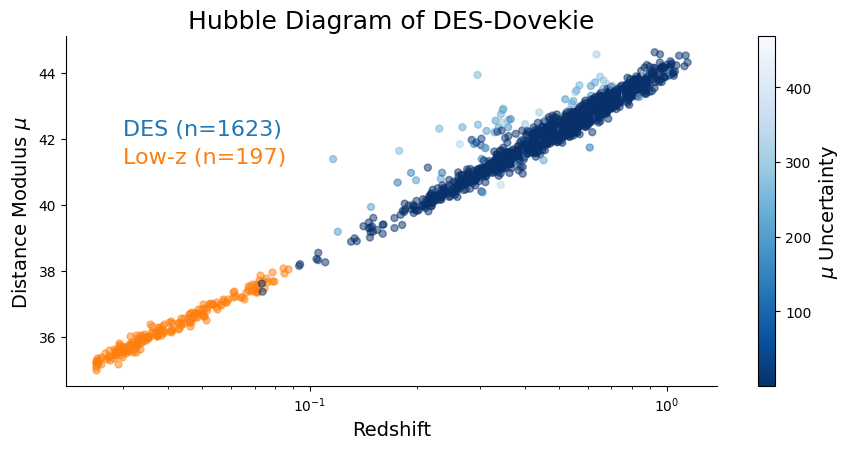

In [57]:
plt.figure(figsize=(9, 4.6))

plt.scatter(low_z['zHD'], low_z['MU'], s=25, color='tab:orange', alpha=0.5)
plt.scatter(high_z['zHD'], high_z['MU'], c=high_z['MUERR'], s=25, cmap='Blues_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ Uncertainty', size=14)

plt.xscale('log')
plt.ylabel('Distance Modulus $\mu$', size=14)
plt.xlabel('Redshift', size=14)
plt.title('Hubble Diagram of DES-Dovekie', size=18)
plt.text(0.03, 42, f"DES (n={len(high_z)})", color='tab:blue', size=16, ha='left', va='bottom')
plt.text(0.03, 41.75, f"Low-z (n={len(low_z)})", color='tab:orange', size=16, ha='left', va='top')
plt.tight_layout()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()